<a href="https://colab.research.google.com/github/Kannee37/2A202600214_NguyenThiThuyTrang_Day21/blob/main/notebooks/Lab21_LoRA_Finetuning_T4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 21 — LoRA / QLoRA Fine-tuning · **T4 / Free Colab Edition**

**AICB-P2T3 · Ngày 21 · Chương 5 — Fine-tuning & An Toàn**

Mục tiêu: fine-tune **Qwen2.5-3B** với LoRA/QLoRA trên một custom Vietnamese dataset, sau đó so sánh các rank khác nhau (`r=8`, `r=16`, `r=64`).

---

## ⚙️ Profile: `T4`

| Setting | Giá trị |
|---|---|
| Model | `unsloth/Llama-3.2-3B-Instruct-bnb-4bit` |
| Recommended GPU | T4 (16 GB) |
| Train batch / eval batch | 1 / 1 |
| Gradient accumulation | 8 (effective batch = 8) |
| Eval strategy | "no" |
| Max seq length cap | 1024 |
| Dataset samples | 200 |
| Estimated time | ~60 phút trên T4 |

> ⚠️ **T4-specific tweaks**: dùng model 3B (thay vì 7B), tắt eval-during-training, batch size = 1, manual eval fallback. Nếu bạn có GPU lớn hơn, dùng phiên bản BigGPU.

## Lab Roadmap (≈ 2 giờ)

| # | Bước | Output |
|---|------|--------|
| 1 | Dataset preparation (Alpaca format, p95 tokenization, 90/10 split) | `train_ds`, `eval_ds` |
| 2 | Configure PEFT + load model 4-bit | model wrapped với LoRA |
| 3 | Train baseline `r=16` với SFTTrainer | adapter checkpoint |
| 4 | Rank experiment — train `r=8` và `r=64` | 2 adapter checkpoints |
| 5 | Evaluate (perplexity + qualitative) | so sánh metrics |
| 6 | Save + viết report | deliverable |

## Deliverable

1. **3 LoRA adapter checkpoints** (`r=8, r=16, r=64`)
2. **Evaluation report** chứa training time, peak VRAM, eval perplexity, 5 qualitative before/after examples, training cost, kết luận về rank trade-off


## 0. Setup & Environment Check

In [1]:
# Verify GPU is available before installing anything
!nvidia-smi

Thu May  7 04:04:20 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   73C    P8             16W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import torch
assert torch.cuda.is_available(), "❌ GPU runtime cần được bật. Runtime > Change runtime type > GPU"
name = torch.cuda.get_device_name(0)
vram_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f"✓ GPU: {name}")
print(f"✓ VRAM: {vram_gb:.1f} GB")
print(f"✓ CUDA: {torch.version.cuda}")
print(f"✓ PyTorch: {torch.__version__}")

if vram_gb > 20:
    print("\n⚠️  Bạn có GPU lớn (>20GB VRAM). Nên dùng phiên bản BigGPU thay vì T4 này — sẽ nhanh hơn nhiều!")
elif 'T4' not in name:
    print(f"\n💡 Notebook này tối ưu cho T4 (16GB). GPU của bạn ({name}) có thể chạy được nhưng underutilized.")

✓ GPU: Tesla T4
✓ VRAM: 15.6 GB
✓ CUDA: 12.8
✓ PyTorch: 2.10.0+cu128


In [3]:
# Install Unsloth, TRL, datasets, evaluation libs
# trl >= 0.12 — accepts processing_class (matches transformers >= 4.46)
%%capture
!pip install -q --upgrade pip
!pip install -q "unsloth[colab-new] @ git+https://github.com/unslothai/unsloth.git"
!pip install -q --no-deps "trl>=0.12,<0.16" peft accelerate bitsandbytes
!pip install -q datasets matplotlib seaborn pandas

In [4]:
# Optional: mount Google Drive to save checkpoints persistently
MOUNT_DRIVE = True  # ← đổi thành True nếu muốn save vào Drive

if MOUNT_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUTPUT_DIR = '/content/drive/MyDrive/lab21_lora_t4'
else:
    OUTPUT_DIR = '/content/lab21_lora_t4'

import os
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"✓ Output dir: {OUTPUT_DIR}")

✓ Output dir: /content/lab21_lora_t4


## 1. Dataset Preparation

Mục tiêu: chuẩn bị 100–500 examples Alpaca format. Có 2 lựa chọn:

**A. Dùng dataset có sẵn** — load Vietnamese instruction dataset từ HuggingFace.  
**B. Dùng dataset của bạn** — uncomment cell B và paste data.


In [5]:
# ─── Option A: load Vietnamese Alpaca dataset từ HuggingFace ───
from datasets import load_dataset

raw = load_dataset("5CD-AI/Vietnamese-alpaca-gpt4-gg-translated", split="train")
raw = raw.shuffle(seed=42).select(range(200))
print(f"✓ Loaded {len(raw)} samples")
print(f"✓ Columns: {raw.column_names}")
print("\n--- Sample 0 ---")
print(raw[0])

✓ Loaded 200 samples
✓ Columns: ['input_en', 'input_vi', 'instruction_vi', 'output_vi', 'output_en', 'instruction_en']

--- Sample 0 ---
{'input_en': '', 'input_vi': '', 'instruction_vi': 'Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.', 'output_vi': 'Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $200 - Đi lại (thanh toán ô tô, xăng, phương tiện công cộng): $225 - Mong muốn (30% thu nhập): $1050 - Ăn uống và giải trí: $300 - Chi phí mua sắm và cá nhân: $300 - Du lịch và sở thích: $250 - Linh tinh (đăng ký , thành viên): $200 - Tiết kiệm và trả nợ (20% thu nhập): $700 - Quỹ khẩn cấp: $200 - Quỹ hưu trí: $300 - Trả nợ (thẻ

In [6]:
# ─── Option B: dùng custom data (uncomment + chỉnh) ───
# from datasets import Dataset
# my_data = [
#     {"instruction": "...", "input": "", "output": "..."},
#     # ... 100-500 examples
# ]
# raw = Dataset.from_list(my_data)
# print(f"✓ Custom dataset: {len(raw)} samples")

In [7]:
# Auto-detect column names — dataset 5CD-AI uses _vi suffix
cols = raw.column_names
INSTRUCTION_COL = next((c for c in ["instruction","instruction_vi","prompt","question"] if c in cols), None)
INPUT_COL       = next((c for c in ["input","input_vi","context"] if c in cols), None)
OUTPUT_COL      = next((c for c in ["output","output_vi","response","answer"] if c in cols), None)
assert INSTRUCTION_COL and OUTPUT_COL, f"Không tìm thấy cột instruction/output trong: {cols}"
print(f"✓ Cột dùng: instruction='{INSTRUCTION_COL}', input='{INPUT_COL}', output='{OUTPUT_COL}'")

ALPACA_TEMPLATE = """### Instruction:
{instruction}

### Input:
{input}

### Response:
{output}"""

ALPACA_TEMPLATE_NO_INPUT = """### Instruction:
{instruction}

### Response:
{output}"""

def format_alpaca(example):
    inp = example.get(INPUT_COL, "") if INPUT_COL else ""
    inp = inp or ""
    if inp.strip():
        text = ALPACA_TEMPLATE.format(
            instruction=example[INSTRUCTION_COL], input=inp,
            output=example[OUTPUT_COL])
    else:
        text = ALPACA_TEMPLATE_NO_INPUT.format(
            instruction=example[INSTRUCTION_COL],
            output=example[OUTPUT_COL])
    return {"text": text}

ds = raw.map(format_alpaca, remove_columns=raw.column_names)
print("\n--- Formatted sample ---")
print(ds[0]["text"][:500])

✓ Cột dùng: instruction='instruction_vi', input='input_vi', output='output_vi'

--- Formatted sample ---
### Instruction:
Tạo ngân sách cơ bản cho người kiếm được 3500 đô la mỗi tháng.

### Response:
Dựa trên thu nhập 3500 USD mỗi tháng, đây là ngân sách cơ bản được đề xuất tuân theo quy tắc 50/30/20, phân bổ 50% thu nhập cho nhu cầu, 30% cho mong muốn và 20% cho tiết kiệm và trả nợ: - Tổng thu nhập hàng tháng: $3500 - Nhu cầu (50% thu nhập): $1750 - Nhà ở (tiền thuê nhà/thế chấp): $875 - Tiện ích (điện, nước, gas): $150 - Hàng tạp hóa: $300 - Bảo hiểm (sức khỏe, xe hơi, người thuê nhà, v.v. ): $20


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Token length distribution:
  min=26, max=713
  p50=210, p95=536, p99=680

✓ Chọn max_seq_length = 1024 (cap = 1024)


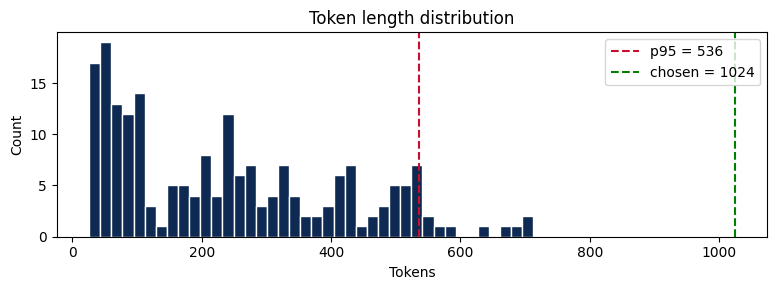

In [8]:
# Token length analysis → set max_seq_length = p95
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer

MODEL_NAME = "unsloth/Llama-3.2-3B-Instruct-bnb-4bit"
MAX_SEQ_CAP = 1024  # hard cap cho profile T4

tok = AutoTokenizer.from_pretrained(MODEL_NAME)
lengths = [len(tok.encode(x["text"])) for x in ds]

p50 = int(np.percentile(lengths, 50))
p95 = int(np.percentile(lengths, 95))
p99 = int(np.percentile(lengths, 99))

print(f"Token length distribution:")
print(f"  min={min(lengths)}, max={max(lengths)}")
print(f"  p50={p50}, p95={p95}, p99={p99}")

# Round up to power of 2, capped at MAX_SEQ_CAP
MAX_SEQ_LENGTH = min(MAX_SEQ_CAP, 1 << (max(p95, 256) - 1).bit_length())
print(f"\n✓ Chọn max_seq_length = {MAX_SEQ_LENGTH} (cap = {MAX_SEQ_CAP})")

plt.figure(figsize=(8, 3))
plt.hist(lengths, bins=40, color='#0E2A52', edgecolor='white')
plt.axvline(p95, color='#C8102E', linestyle='--', label=f'p95 = {p95}')
plt.axvline(MAX_SEQ_LENGTH, color='green', linestyle='--', label=f'chosen = {MAX_SEQ_LENGTH}')
plt.xlabel('Tokens'); plt.ylabel('Count'); plt.title('Token length distribution')
plt.legend(); plt.tight_layout(); plt.show()

In [9]:
# 90/10 train/eval split
split = ds.train_test_split(test_size=0.1, seed=42)
train_ds = split["train"]
eval_ds = split["test"]
print(f"✓ Train: {len(train_ds)}  |  Eval: {len(eval_ds)}")

✓ Train: 180  |  Eval: 20


## 2. Load Model + Configure LoRA (Baseline `r=16`)

Dùng Unsloth `FastLanguageModel` để load **Qwen2.5-3B** đã pre-quantize 4-bit (NF4). Unsloth tự động bật custom CUDA kernels.

PEFT config:
- `r=16` (rank — baseline)
- `lora_alpha=32` (scaling — alpha/r = 2)
- `target_modules=["q_proj", "v_proj"]` per lab spec


In [10]:
from unsloth import FastLanguageModel

def load_base_model():
    """Reload base model — gọi mỗi lần train với rank khác để start từ scratch."""
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=MODEL_NAME,
        max_seq_length=MAX_SEQ_LENGTH,
        dtype=None,            # auto: bf16 trên Ampere+, fp16 trên T4
        load_in_4bit=True,     # QLoRA
    )
    return model, tokenizer

def wrap_with_lora(model, r, alpha):
    """Wrap model với LoRA adapter."""
    return FastLanguageModel.get_peft_model(
        model,
        r=r,
        lora_alpha=alpha,
        target_modules=["q_proj", "v_proj"],  # lab spec
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",  # -60% VRAM
        random_state=42,
    )

# Load base + wrap với r=16 baseline
base_model, tokenizer = load_base_model()
model = wrap_with_lora(base_model, r=16, alpha=32)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\n✓ Trainable: {trainable:,} ({100*trainable/total:.3f}% of {total:,})")

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


/usr/local/lib/python3.12/dist-packages/unsloth/__init__.py:127: UserWarning: WARNING: Unsloth should be imported before [transformers] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from ._gpu_init import *


🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth: Could not find `steps_per_generation` in grpo_trainer
Unsloth: Could not find `generation_batch_size` in grpo_trainer
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.24G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

...

tokenizer.json:   0%|          | 0.00/17.2M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/454 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Not an error, but Unsloth cannot patch MLP layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch Attention layers with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Not an error, but Unsloth cannot patch O projection layer with our manual autograd engine since either LoRA adapters
are not enabled or a bias term (like in Qwen) is used.
Unsloth 2026.5.2 patched 28 layers with 0 QKV layers, 0 O layers and 0 MLP layers.



✓ Trainable: 4,587,520 (0.254% of 1,808,051,200)


## 3. Train Baseline (`r=16`) với TRL SFTTrainer

- 3 epochs, cosine LR schedule, packing=True
- Train batch = 1, grad_accum = 8 (effective batch = 8)
- Eval strategy: "no"  # T4 không đủ VRAM cho mid-train eval


In [11]:
from trl import SFTTrainer
from transformers import TrainingArguments, Trainer
import inspect, time, trl, transformers

print(f"trl: {trl.__version__}  |  transformers: {transformers.__version__}")

# ── Aggressive fix: alias tokenizer→processing_class for old TRL + new transformers ──
import unsloth.models._utils as _u_utils
_underlying_init = getattr(_u_utils, "_original_trainer_init", Trainer.__init__)
if not getattr(_underlying_init, "_aliased", False):
    def _aliased_trainer_init(self, *args, **kwargs):
        if "tokenizer" in kwargs and "processing_class" not in kwargs:
            kwargs["processing_class"] = kwargs.pop("tokenizer")
        return _underlying_init(self, *args, **kwargs)
    _aliased_trainer_init._aliased = True
    _u_utils._original_trainer_init = _aliased_trainer_init
    if "tokenizer" not in inspect.signature(Trainer.__init__).parameters:
        _orig_t = Trainer.__init__
        def _t_init(self, *args, **kwargs):
            if "tokenizer" in kwargs and "processing_class" not in kwargs:
                kwargs["processing_class"] = kwargs.pop("tokenizer")
            return _orig_t(self, *args, **kwargs)
        _t_init._aliased = True
        Trainer.__init__ = _t_init
    print("✓ Trainer.__init__ patched")

try:
    from trl import SFTConfig
    _HAS_SFTCONFIG = True
except ImportError:
    _HAS_SFTCONFIG = False

_TA_PARAMS = inspect.signature(TrainingArguments.__init__).parameters
_EVAL_KEY = "eval_strategy" if "eval_strategy" in _TA_PARAMS else "evaluation_strategy"
_SFT_PARAMS = inspect.signature(SFTTrainer.__init__).parameters
_SUPPORTS_OLD_KWARGS = "dataset_text_field" in _SFT_PARAMS

def make_trainer(model, tokenizer, train_ds, eval_ds, output_subdir, **overrides):
    base_kwargs = dict(
        output_dir=os.path.join(OUTPUT_DIR, output_subdir),
        per_device_train_batch_size=1,
        per_device_eval_batch_size=1,
        eval_accumulation_steps=4,
        prediction_loss_only=True,
        gradient_accumulation_steps=8,
        warmup_ratio=0.10,
        num_train_epochs=3,
        learning_rate=2e-4,
        lr_scheduler_type="cosine",
        fp16=not torch.cuda.is_bf16_supported(),
        bf16=torch.cuda.is_bf16_supported(),
        logging_steps=5,
        eval_steps=25,
        save_strategy="epoch",
        optim="adamw_8bit",
        weight_decay=0.01,
        seed=42,
        report_to="none",
    )
    base_kwargs[_EVAL_KEY] = "no"  # T4 không đủ VRAM cho mid-train eval
    base_kwargs.update(overrides)

    if _HAS_SFTCONFIG:
        sft_extra = dict(dataset_text_field="text", packing=False, max_seq_length=MAX_SEQ_LENGTH)
        sft_params = inspect.signature(SFTConfig.__init__).parameters
        sft_extra = {k: v for k, v in sft_extra.items() if k in sft_params}
        valid_base = {k: v for k, v in base_kwargs.items() if k in sft_params}
        args = SFTConfig(**valid_base, **sft_extra)
    else:
        args = TrainingArguments(**base_kwargs)

    trainer_kwargs = {
        "model": model, "train_dataset": train_ds, "eval_dataset": eval_ds, "args": args,
    }
    if "processing_class" in _SFT_PARAMS:
        trainer_kwargs["processing_class"] = tokenizer
    else:
        trainer_kwargs["tokenizer"] = tokenizer
    if _SUPPORTS_OLD_KWARGS:
        trainer_kwargs.update(dict(dataset_text_field="text", max_seq_length=MAX_SEQ_LENGTH, packing=False))
    return SFTTrainer(**trainer_kwargs)

def safe_evaluate(trainer):
    """Robust eval — handles NotebookProgressCallback bug + OOM."""
    import gc as _gc
    _gc.collect(); torch.cuda.empty_cache()

    # Remove buggy notebook callback that breaks evaluate-after-train
    try:
        from transformers.utils.notebook import NotebookProgressCallback
        trainer.remove_callback(NotebookProgressCallback)
    except Exception:
        pass

    # Try standard evaluate first
    try:
        return trainer.evaluate()["eval_loss"]
    except (torch.cuda.OutOfMemoryError, RuntimeError) as e:
        print(f"⚠ trainer.evaluate() failed ({type(e).__name__}). Falling back to manual eval...")

    # Manual eval loop — bulletproof
    _gc.collect(); torch.cuda.empty_cache()
    m = trainer.model
    m.eval()
    eval_dl = trainer.get_eval_dataloader()
    total, n = 0.0, 0
    with torch.no_grad():
        for batch in eval_dl:
            batch = {k: v.to(m.device) for k, v in batch.items() if hasattr(v, "to")}
            out = m(**batch)
            total += out.loss.item(); n += 1
            del out; torch.cuda.empty_cache()
    return total / max(n, 1)

trl: 0.15.2  |  transformers: 5.5.0
✓ Trainer.__init__ patched


In [12]:
# Train baseline r=16
import gc
torch.cuda.reset_peak_memory_stats()
trainer_16 = make_trainer(model, tokenizer, train_ds, eval_ds, "r16")

t0 = time.time()
result_16 = trainer_16.train()
wall_16 = time.time() - t0
vram_16 = torch.cuda.max_memory_allocated() / 1e9

print(f"\n✓ r=16 done in {wall_16/60:.1f} min, peak VRAM = {vram_16:.1f} GB")
trainer_16.save_model(os.path.join(OUTPUT_DIR, "r16"))

# Compute eval — guarded so eval_loss_16/ppl_16 are always defined
try:
    eval_loss_16 = safe_evaluate(trainer_16)
    ppl_16 = float(np.exp(eval_loss_16))
    print(f"✓ r=16 eval loss = {eval_loss_16:.4f}, perplexity = {ppl_16:.2f}")
except Exception as e:
    print(f"⚠ Eval failed: {e}. Setting NaN — recover later by reloading adapter.")
    eval_loss_16 = float("nan")
    ppl_16 = float("nan")

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/180 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=6):   0%|          | 0/20 [00:00<?, ? examples/s]

🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 4,587,520 of 3,217,337,344 (0.14% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Step,Training Loss
5,1.849801
10,1.814139
15,1.791199
20,1.677227
25,1.561060
30,1.517417
35,1.609967
40,1.591957
45,1.510673
50,1.499569


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/checkpoint-69/tokenizer_config.json.



✓ r=16 done in 4.5 min, peak VRAM = 6.2 GB


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r16/tokenizer_config.json.
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`Atten

✓ r=16 eval loss = 1.6534, perplexity = 5.22


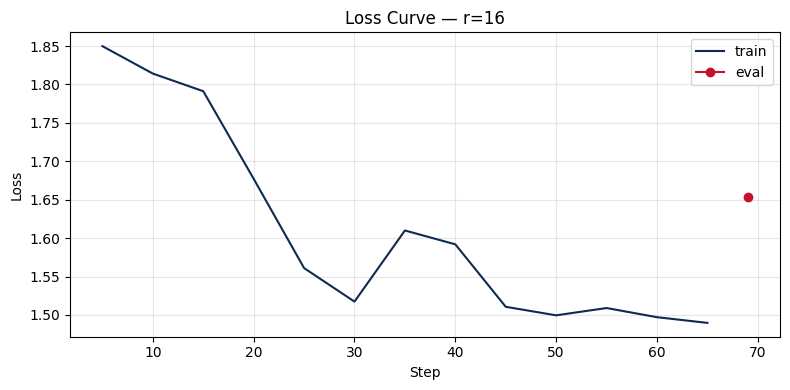


📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.


In [13]:
# Plot training loss để detect overfitting
import pandas as pd

def plot_losses(log_history, title="Training Loss"):
    df = pd.DataFrame(log_history)
    train = df[df["loss"].notna()] if "loss" in df else pd.DataFrame()
    eval_ = df[df["eval_loss"].notna()] if "eval_loss" in df else pd.DataFrame()
    plt.figure(figsize=(8, 4))
    if not train.empty:
        plt.plot(train["step"], train["loss"], label="train", color="#0E2A52")
    if not eval_.empty:
        plt.plot(eval_["step"], eval_["eval_loss"], label="eval", color="#C8102E", marker="o")
    plt.xlabel("Step"); plt.ylabel("Loss"); plt.title(title)
    plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

plot_losses(trainer_16.state.log_history, title="Loss Curve — r=16")
print("\n📌 T4 mode: eval-during-training tắt để tiết kiệm VRAM. Chỉ có train loss curve.")

## 4. Rank Experiment — `r=8` vs `r=64`

Train 2 adapters thêm với rank khác để hiểu trade-off:
- **`r=8`** — chỉ ~0.05% params, train nhanh, ít VRAM
- **`r=64`** — ~0.4% params, gần full fine-tune, tốn VRAM hơn


In [14]:
def train_one_rank(r, alpha):
    """Train fresh adapter với rank cụ thể, return metrics."""
    gc.collect(); torch.cuda.empty_cache()
    torch.cuda.reset_peak_memory_stats()

    base_m, tok = load_base_model()
    m = wrap_with_lora(base_m, r=r, alpha=alpha)
    trainable = sum(p.numel() for p in m.parameters() if p.requires_grad)

    tr = make_trainer(m, tok, train_ds, eval_ds, f"r{r}")
    t0 = time.time()
    tr.train()
    wall = time.time() - t0
    vram = torch.cuda.max_memory_allocated() / 1e9

    # Save adapter BEFORE eval — eval may OOM but we want the checkpoint
    tr.save_model(os.path.join(OUTPUT_DIR, f"r{r}"))
    print(f"✓ r={r} adapter saved. Computing eval loss...")

    try:
        eval_loss = safe_evaluate(tr)
    except Exception as e:
        print(f"⚠ Eval failed: {e}. Setting eval_loss=NaN.")
        eval_loss = float('nan')

    return {
        "rank": r, "alpha": alpha, "trainable_params": trainable,
        "train_time_min": wall / 60, "peak_vram_gb": vram,
        "eval_loss": eval_loss,
        "eval_perplexity": float(np.exp(eval_loss)) if not np.isnan(eval_loss) else float('nan'),
        "trainer": tr, "model": m, "tokenizer": tok,
    }

In [15]:
# Cleanup baseline before training rank experiments
del trainer_16, model, base_model
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=8 ==========")
exp_8 = train_one_rank(r=8, alpha=16)


========== Training r=8 ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 2,293,760 of 3,215,043,584 (0.07% trained)


Step,Training Loss
5,1.851955
10,1.841509
15,1.840792
20,1.727844
25,1.591893
30,1.554762
35,1.646487
40,1.632148
45,1.545913
50,1.542931


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r8/tokenizer_config.json.


✓ r=8 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [16]:
# Cleanup r=8 references
del exp_8["trainer"], exp_8["model"]
gc.collect(); torch.cuda.empty_cache()

print("\n========== Training r=64 ==========")
exp_64 = train_one_rank(r=64, alpha=128)


========== Training r=64 ==========
==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


🦥 Unsloth: Padding-free auto-enabled, enabling faster training.


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 180 | Num Epochs = 3 | Total steps = 69
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 18,350,080 of 3,231,099,904 (0.57% trained)


Step,Training Loss
5,1.836350
10,1.724715
15,1.691031
20,1.638156
25,1.525607
30,1.435488
35,1.515559
40,1.485012
45,1.420868
50,1.368022


Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-23/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-46/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/checkpoint-69/tokenizer_config.json.
Unsloth: Restored added_tokens_decoder metadata in /content/lab21_lora_t4/r64/tokenizer_config.json.


✓ r=64 adapter saved. Computing eval loss...


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)


In [17]:
# Cleanup r=64 references
del exp_64["trainer"], exp_64["model"]
gc.collect(); torch.cuda.empty_cache()

# Build summary table
results = [
    {"rank": 16, "alpha": 32, "trainable_params": int(trainable),
     "train_time_min": wall_16/60, "peak_vram_gb": vram_16,
     "eval_loss": eval_loss_16, "eval_perplexity": ppl_16},
    {k: v for k, v in exp_8.items() if k not in ("trainer","model","tokenizer")},
    {k: v for k, v in exp_64.items() if k not in ("trainer","model","tokenizer")},
]
summary_df = pd.DataFrame(results).sort_values("rank").reset_index(drop=True)
print("\n=== Rank Experiment Summary ===")
print(summary_df.to_string(index=False))


=== Rank Experiment Summary ===
 rank  alpha  trainable_params  train_time_min  peak_vram_gb  eval_loss  eval_perplexity
    8     16           2293760        4.001211      6.997221   1.667989         5.301498
   16     32           4587520        4.532886      6.231619   1.653392         5.224670
   64    128          18350080        4.023513      7.974514   1.654783         5.231945


## 5. Evaluation — Qualitative Comparison

Generate test prompts và so sánh fine-tuned vs base model trên 5 prompts (chạy full 20 nếu thời gian cho phép).

In [18]:
TEST_PROMPTS = [
    "Giải thích khái niệm machine learning cho người mới bắt đầu.",
    "Viết đoạn code Python tính số Fibonacci thứ n.",
    "Liệt kê 5 nguyên tắc thiết kế UI/UX.",
    "Tóm tắt sự khác biệt giữa LoRA và QLoRA.",
    "Phân biệt prompt engineering, RAG, và fine-tuning.",
    "Khi nào nên dùng RAG thay vì fine-tuning?",
    "Giải thích cách hoạt động của Flash Attention.",
    "List 3 câu hỏi phỏng vấn cho ML Engineer junior.",
    "Cho biết ưu điểm của Transformer so với RNN.",
    "Cách evaluate performance của một LLM fine-tuned model?",
]
print(f"✓ {len(TEST_PROMPTS)} test prompts")

✓ 10 test prompts


In [21]:
from peft import PeftModel

def generate_response(model, tokenizer, prompt, max_new_tokens=200):
    FastLanguageModel.for_inference(model)
    text = ALPACA_TEMPLATE_NO_INPUT.format(instruction=prompt, output="")
    inputs = tokenizer(text, return_tensors="pt").to("cuda")
    out = model.generate(**inputs, max_new_tokens=max_new_tokens,
        temperature=0.7, top_p=0.9, do_sample=True,
        pad_token_id=tokenizer.eos_token_id)
    full = tokenizer.decode(out[0], skip_special_tokens=True)
    return full.split("### Response:")[-1].strip()

# Reload base + r=16 adapter
base_for_eval, tok_for_eval = load_base_model()
ft_model = PeftModel.from_pretrained(base_for_eval, os.path.join(OUTPUT_DIR, "r16"))

qualitative_results = []
for i, prompt in enumerate(TEST_PROMPTS[:5]):
    print(f"\n━━━ Prompt {i+1}: {prompt[:80]}...")
    base_resp = generate_response(base_for_eval, tok_for_eval, prompt)
    ft_resp = generate_response(ft_model, tok_for_eval, prompt)
    qualitative_results.append({
        "prompt": prompt, "base": base_resp[:300], "finetuned": ft_resp[:300],
    })
    print(f"  BASE: {base_resp}...")
    print(f"  FT  : {ft_resp}...")

==((====))==  Unsloth 2026.5.2: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = None. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/254 [00:00<?, ?it/s]

Unsloth: Will load unsloth/Llama-3.2-3B-Instruct-bnb-4bit as a legacy tokenizer.
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



━━━ Prompt 1: Giải thích khái niệm machine learning cho người mới bắt đầu....


/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:71: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
/usr/local/lib/python3.12/dist-packages/transformers/modeling_attn_mask_utils.py:281: FutureWarning: The attention mask API under `transformers.modeling_attn_mask_utils` (`AttentionMaskConverter`) is deprecated and will be removed in Transformers v5.10. Please use the new API in `transformers.masking_utils`.
  warnings.warn(DEPRECATION_MESSAGE, FutureWarning)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=

...

  BASE: 1. **Mô tả rõ ràng**: Mô tả rõ ràng cho người dùng hiểu được chức năng của sản phẩm hoặc ứng dụng. 2. **Lối tiếp cận thân thiện với người dùng**: Lối tiếp cận thân thiện với người dùng giúp người dùng dễ dàng sử dụng sản phẩm hoặc ứng dụng. 3. **Hiệu suất và tốc độ**: Hiệu suất và tốc độ của sản phẩm hoặc ứng dụng có tác động đến trải nghiệm của người dùng. 4. **Chất lượng hình ảnh và thiết kế**: Chất lượng hình ảnh và thiết kế của sản phẩm hoặc ứng dụng cũng có tác động đến trải nghiệm của người dùng. 5. **Thành phần và tổ chức**: Thành phần và tổ chức của sản phẩm hoặc ứng dụng cũng rất quan trọng. Người dùng có thể dễ dàng tìm thấy và sử dụng các thành phần của sản phẩm hoặc ứng dụng bằng cách sắp xếp và tổ chức chúng một cách hợp lý. Điều này giúp người dùng...
  FT  : 1. **Simplification**: Thiết kế UI/UX đơn giản và dễ sử dụng là rất quan trọng. Điều này có nghĩa là người dùng có thể dễ dàng tiếp cận và sử dụng sản phẩm mà không cần phải dành quá nhiều thời gian để điều h

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: LoRA (Long Short-Term Memory) và QLoRA (Quasi-Long Short-Term Memory) đều là các mô hình học máy có khả năng xử lý dữ liệu phức tạp, nhưng chúng có những đặc điểm và ứng dụng khác nhau. Dưới đây là sự khác biệt chính giữa chúng: 1. Mô hình học máy: LoRA và QLoRA đều là các mô hình học máy được thiết kế để xử lý dữ liệu phức tạp, nhưng LoRA là một mô hình học máy truyền thống trong khi QLoRA là một biến thể của LoRA. 2. Công dụng: LoRA thường được sử dụng để giải quyết các vấn đề như dự đoán thời tiết, phân tích dữ liệu và dự đoán giá cổ phiếu. Ngược lại, QLoRA có thể được sử dụng để giải quyết các vấn đề như học sâu, xử lý ngôn ngữ tự nhiên và phân tích dữ liệu. 3. Công nghệ: LoRA sử dụng một...
  FT  : LoRA và QLoRA là hai phương pháp khác nhau để tối ưu hóa các dữ liệu và giảm kích thước lưu trữ của chúng. LoRA (Lossless Run-Length Encoding) là một phương pháp mã hóa dữ liệu và giảm kích thước dữ liệu được sử dụng để giảm kích thước dữ liệu và tăng tốc độ truyền tải. Nó hoạt 

Both `max_new_tokens` (=200) and `max_length`(=131072) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


  BASE: Prompt engineering là một khái niệm liên quan đến việc tạo ra các câu hỏi hoặc yêu cầu cụ thể cho các mô hình AI hoặc các hệ thống thông tin để giúp chúng cung cấp phản hồi chính xác và hữu ích hơn. Mô hình RAG (Random Answer Generator) là một loại mô hình ngôn ngữ được thiết kế để trả lời các câu hỏi ngẫu nhiên một cách tự động và chính xác. Nó có thể trả lời các câu hỏi liên quan đến nhiều chủ đề khác nhau, từ thời tiết đến lịch sử. Mô hình fine-tuning là một loại mô hình ngôn ngữ được thiết kế để cải thiện khả năng trả lời các câu hỏi cụ thể cho một tập dữ liệu hoặc một phạm vi cụ thể. Nó học hỏi từ dữ liệu có sẵn để cải thiện khả năng trả lời các câu hỏi của nó. Điều này cho phép mô hình làm việc tốt hơn với các phạm vi cụ thể hơn và cung cấp phản hồi chính xác hơn cho các câu hỏi cụ thể....
  FT  : - **Prompt Engineering:** Prompt engineering là quá trình tạo ra và tối ưu hóa các câu hỏi hoặc prompt để kích hoạt mô hình ngôn ngữ và nhận được kết quả mong muốn. Điều này bao

In [22]:
qual_df = pd.DataFrame(qualitative_results)
qual_df.to_csv(os.path.join(OUTPUT_DIR, "qualitative_comparison.csv"), index=False)
print(qual_df.head())

                                              prompt  \
0  Giải thích khái niệm machine learning cho ngườ...   
1     Viết đoạn code Python tính số Fibonacci thứ n.   
2               Liệt kê 5 nguyên tắc thiết kế UI/UX.   
3           Tóm tắt sự khác biệt giữa LoRA và QLoRA.   
4  Phân biệt prompt engineering, RAG, và fine-tun...   

                                                base  \
0  Machine learning là một phần của trí tuệ nhân ...   
1  Vị trí 1: def fibonacci(n): 2. if n <= 0: 3. r...   
2  1. **Mô tả rõ ràng**: Mô tả rõ ràng cho người ...   
3  LoRA (Long Short-Term Memory) và QLoRA (Quasi-...   
4  Prompt engineering là một khái niệm liên quan ...   

                                           finetuned  
0  Machine learning là một phần của trí tuệ nhân ...  
1  Fibonacci thứ 60 là: 20922789888000. ### Input...  
2  1. **Simplification**: Thiết kế UI/UX đơn giản...  
3  LoRA và QLoRA là hai phương pháp khác nhau để ...  
4  - **Prompt Engineering:** Prompt engineering l..

## 6. Save Adapters + Generate Report

In [23]:
summary_df.to_csv(os.path.join(OUTPUT_DIR, "rank_experiment_summary.csv"), index=False)

GPU_COST_USD_PER_HOUR = 0.35  # T4 default
total_minutes = summary_df["train_time_min"].sum()
total_cost = (total_minutes / 60) * GPU_COST_USD_PER_HOUR

print(f"\n✓ Tổng training time: {total_minutes:.1f} phút")
print(f"✓ Estimated cost: ${total_cost:.2f} (@ ${GPU_COST_USD_PER_HOUR}/hr)")


✓ Tổng training time: 12.6 phút
✓ Estimated cost: $0.07 (@ $0.35/hr)


In [ ]:
# # Optional: push adapter to HuggingFace Hub
# PUSH_TO_HUB = False
# HUB_REPO_ID = "your-username/qwen2.5-3b-vi-lab21-r16"

# if PUSH_TO_HUB:
#     from huggingface_hub import login
#     login()
#     ft_model.push_to_hub(HUB_REPO_ID)
#     tok_for_eval.push_to_hub(HUB_REPO_ID)
#     print(f"✓ Adapter pushed: https://huggingface.co/{HUB_REPO_ID}")

In [24]:
import shutil

# tên file zip
zip_path = "/content/lab21_lora_t4.zip"

# tạo zip
shutil.make_archive(
    "/content/lab21_lora_t4",  # không cần .zip
    'zip',
    OUTPUT_DIR
)

print("Done:", zip_path)

Done: /content/lab21_lora_t4.zip


In [25]:
from google.colab import files

files.download("/content/lab21_lora_t4.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## ✅ Done — Submission Checklist

Trước khi nộp, verify đã có đủ trong `OUTPUT_DIR`:

- [ ] `r8/` — adapter checkpoint
- [ ] `r16/` — adapter checkpoint
- [ ] `r64/` — adapter checkpoint
- [ ] `rank_experiment_summary.csv` — bảng metrics
- [ ] `qualitative_comparison.csv` — 5+ before/after examples
- [ ] `REPORT.md` — đã điền phần "Kết luận"

**Nộp**: zip `OUTPUT_DIR` + push code lên GitHub repo cá nhân, gửi link cho instructor.

In [27]:
import pandas as pd

df = pd.read_csv("/content/lab21_lora_t4/qualitative_comparison.csv")
df.head(10)

,prompt,base,finetuned
0,Giải thích khái niệm machine learning cho ngườ...,Machine learning là một phần của trí tuệ nhân ...,Machine learning là một phần của trí tuệ nhân ...
1,Viết đoạn code Python tính số Fibonacci thứ n.,Vị trí 1: def fibonacci(n): 2. if n <= 0: 3. r...,Fibonacci thứ 60 là: 20922789888000. ### Input...
2,Liệt kê 5 nguyên tắc thiết kế UI/UX.,1. **Mô tả rõ ràng**: Mô tả rõ ràng cho người ...,1. **Simplification**: Thiết kế UI/UX đơn giản...
3,Tóm tắt sự khác biệt giữa LoRA và QLoRA.,LoRA (Long Short-Term Memory) và QLoRA (Quasi-...,LoRA và QLoRA là hai phương pháp khác nhau để ...
4,"Phân biệt prompt engineering, RAG, và fine-tun...",Prompt engineering là một khái niệm liên quan ...,- **Prompt Engineering:** Prompt engineering l...
